# **DP bedload model in 2d: Scaling analysis**

<hr>

## Preliminaries

In [15]:
from essentials import *
viz = Viz(dpi=125)

n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float
n_lattices: int
lattices: NDArray
tracking: NDArray

In [16]:
def plot(viz, expt, parameters, tracking,) -> None:
    name = make_name(parameters, "ρmean", None,)
    # title = make_title(parameters, None,)
    title = rf"$p_1={expt['p_1']}$  $p_2={expt['p_2']}$  $n={expt['n_iterations']}$"
    δ = 0.45051
    scale = expt["scale"]
    viz.lattice_statistic(
        name,
        title,
        tracking,
        choices=("time", "ρ_mean"),
        labels=None,
        #     "Order parameter  $\\widebar{\\rho}(t)$", 
        #     "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        #     "${\\delta}$",
        # ),
        exponent=-δ, 
        scale=scale,
        i_offset=0,
        do_ref_curve=True,
        fig_size=(4, 3,),
    )
    # plt.ylim(None, 1)
    plt.show()

In [17]:
def fit_tail(parameters, tracking) -> tuple[float, float]:
    i_offset: int = parameters.n_iterations//5
    t: NDArray = tracking["time"][i_offset:]
    ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
    (exponent, scale, r_value, p_value, std_err) \
        = linregress(np.log(t), np.log(ρ_mean))
    # print(f"t range: {t[0]}-{t[-1]}")
    print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")
    return (float(exponent), float(scale),)

In [18]:
def compute_tail_mean(parameters,) -> float:
    i_offset: int = parameters.n_iterations//2
    t: NDArray = tracking["time"][i_offset:]
    ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
    mean_ρ_mean: float = np.mean(ρ_mean)
    print(f"t range: {t[0]}-{t[-1]}")
    print(f"Tail mean: <ρ> = {(mean_ρ_mean):e}")
    # print(f"External:  p_conj = {(parameters.p_conj):g}")
    # print(f"Tail mean/p3:  <ρ>/p_conj = {round(mean_ρ_mean/parameters.p_conj, 1)}")
    return float(mean_ρ_mean)

<hr>

## Parameters

In [19]:
def set_parameters(expt):
    class Parameters:
        growth_model = GrowthModel.BedloadB
        dim = Dimension.D2
        n_x: int = expt["n_xy"]
        n_y: int = expt["n_xy"]
        n_z: int = 1
        p_1: float = expt["p_1"]
        p_2: float = expt["p_2"]
        p_conj: float = 0 # 1e-4
        p_nbr: float = 0.5
        p_diag: float = 0.5
        n_iterations: int = expt["n_iterations"] 
        sample_period: int = 0
        random_seed: int = expt["seed"] if expt["seed"] is not None else 1
        # initial_condition = InitialCondition.CentralCell
        # initial_condition = InitialCondition.EdgeCell
        initial_condition = InitialCondition.Randomized
        p_initial: float = 0.1
        topology_x = Topology.Periodic
        topology_y = Topology.Periodic
        topology_z = Topology.Unspecified
        bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
        bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
        bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
        bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
        bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
        bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
        do_edge_buffering: bool = True
        processing = Processing.Parallel
        n_threads: int = 16
    return Parameters()

<hr>

## Analysis

In [20]:
do_recompute: bool = False
do_p2 = False

In [21]:
n_xy = 500

if do_p2:
    n_iterations = 5_000
    expts_tuple = (
        dict(p_1=0.575,    p_2=0.90, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.33777937520284457,),
        dict(p_1=0.575,    p_2=0.990, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.2690118062705938,),
        dict(p_1=0.575,    p_2=0.70, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.20681123976960433,),
        dict(p_1=0.575,    p_2=0.60, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.14921053984234472,),
        dict(p_1=0.575,    p_2=0.55, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.1198474710856365,),
        dict(p_1=0.575,    p_2=0.50, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.08733582438841975,),
        dict(p_1=0.575,    p_2=0.45, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.04876168936459232,),
        dict(p_1=0.575,    p_2=0.41, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.017081640350901265,),
        dict(p_1=0.575,    p_2=0.40, n_xy=n_xy, n_iterations=50_000, seed=1, scale=1, tail_mean_ρ=0.00047958647360423124,),
    )
    grouped_expts = {
        expt["p_2"]: expt for i, expt in enumerate(expts_tuple)
    }
else:
    n_iterations = 5_000
    m_iterations = 200_000

    expts_tuple = (
        dict(p_1=1.00,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.0,),
        dict(p_1=0.95,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.9283010082955488,),
        dict(p_1=0.90,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.8517892698039058,),
        dict(p_1=0.85,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.7694662109561616,),
        dict(p_1=0.80,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.6797660745261225,),
        dict(p_1=0.75,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.5800302321673775,),
        dict(p_1=0.70,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0.46548806422870975,),
        dict(p_1=0.65,    p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0.32405856854226567,),
        dict(p_1=0.62,    p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0.21006421379595672,),
        dict(p_1=0.60,    p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0.09347113744659502,),
        dict(p_1=0.595,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0.04013863534664404,),
        dict(p_1=0.5945,  p_2=0.0, n_xy=n_xy, n_iterations=50_000, seed=1, scale=1, tail_mean_ρ=0.033163711336456216,),
        dict(p_1=0.594,   p_2=0.0, n_xy=n_xy, n_iterations=50_000, seed=1, scale=1, tail_mean_ρ=0.02358432381036714,),
        dict(p_1=0.5935,  p_2=0.0, n_xy=n_xy, n_iterations=200_000, seed=1, scale=1, tail_mean_ρ=0.007081959606105384,),
        dict(p_1=0.5934,  p_2=0.0, n_xy=n_xy, n_iterations=200_000, seed=1, scale=1, tail_mean_ρ=0.004614760772485601,),
        # dict(p_1=0.59337, p_2=0.0, n_xy=n_xy, n_iterations=50_000, seed=1, scale=1, tail_mean_ρ=0.007280740645192801,),
        # dict(p_1=0.58,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0,),
        # dict(p_1=0.56,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0,),
        # dict(p_1=0.51,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0,),
        # dict(p_1=0.45,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, tail_mean_ρ=0,),
    )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.478516e-01,),
    #     dict(p_1=0.90,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.898342e-01,),
    #     dict(p_1=0.85,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.244839e-01,),
    #     dict(p_1=0.80,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.499310e-01,),
    #     dict(p_1=0.75,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.630610e-01,),
    #     dict(p_1=0.70,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=5.582801e-01,),
    #     dict(p_1=0.65,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=4.251317e-01,),
    #     dict(p_1=0.60,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=2.279497e-01,),
    #     dict(p_1=0.5900,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.384130e-02,),
    #     dict(p_1=0.5890,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.430133e-02,),
    #     dict(p_1=0.5880,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.285815e-02,),
    #     dict(p_1=0.5870,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=4.646714e-02,),
    #     dict(p_1=0.5860,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=3.436060e-02,),
    #     dict(p_1=0.5850,    p_2=0.2, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=1.899029e-02,),
    #     dict(p_1=0.5840,    p_2=0.2, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=0.,),
    #     dict(p_1=0.5838,    p_2=0.2, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=0.,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.478516e-01,),
    #     dict(p_1=0.90,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.898342e-01,),
    #     dict(p_1=0.85,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.244839e-01,),
    #     dict(p_1=0.80,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.499310e-01,),
    #     dict(p_1=0.75,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.630610e-01,),
    #     dict(p_1=0.70,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=5.582801e-01,),
    #     dict(p_1=0.65,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=4.251317e-01,),
    #     dict(p_1=0.60,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=2.279497e-01,),
    #     dict(p_1=0.58,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.289189e-02,),
    #     dict(p_1=0.579,   p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.347947e-02,),
    #     dict(p_1=0.578,   p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=5.583668e-02,),
    #     dict(p_1=0.577,   p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=3.998964e-02,),
    #     dict(p_1=0.5760,  p_2=0.4, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=1.212315e-02,),
    #     dict(p_1=0.5755,  p_2=0.4, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=0,),
    #     dict(p_1=0.5750,  p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.579307e-01,),
    #     dict(p_1=0.90,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.101171e-01,),
    #     dict(p_1=0.85,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.549435e-01,),
    #     dict(p_1=0.80,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.903465e-01,),
    #     dict(p_1=0.75,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.129436e-01,),
    #     dict(p_1=0.70,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.169763e-01,),
    #     dict(p_1=0.65,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=4.915130e-01,),
    #     dict(p_1=0.60,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=3.059556e-01,),
    #     dict(p_1=0.57,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.861621e-02,),
    #     dict(p_1=0.5655,    p_2=0.6, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=1.753605e-02,),
    #     dict(p_1=0.5653,    p_2=0.6, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=0,),
    #     dict(p_1=0.5650,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.682188e-01,),
    #     dict(p_1=0.90,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.313078e-01,),
    #     dict(p_1=0.85,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.876666e-01,),
    #     dict(p_1=0.80,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.351150e-01,),
    #     dict(p_1=0.75,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.701547e-01,),
    #     dict(p_1=0.70,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.869096e-01,),
    #     dict(p_1=0.65,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=5.741579e-01,),
    #     dict(p_1=0.60,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=4.033921e-01,),
    #     dict(p_1=0.57,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=2.324365e-01,),
    #     dict(p_1=0.56,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.411233e-01,),
    #     dict(p_1=0.555,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.739605e-02,),
    #     dict(p_1=0.554,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=5.236005e-02,),
    #     dict(p_1=0.553,    p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=6.592255e-03,),
    #     dict(p_1=0.552,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=0,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.782101e-01,),
    #     dict(p_1=0.90,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.523538e-01,),
    #     dict(p_1=0.85,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=9.210114e-01,),
    #     dict(p_1=0.80,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.821824e-01,),
    #     dict(p_1=0.75,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=8.326867e-01,),
    #     dict(p_1=0.70,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=7.668132e-01,),
    #     dict(p_1=0.65,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=6.735684e-01,),
    #     dict(p_1=0.60,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=5.264920e-01,),
    #     dict(p_1=0.55,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, tail_mean_ρ=2.175521e-01,),
    #     dict(p_1=0.540,   p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=5.808012e-02,),
    #     dict(p_1=0.539,   p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=7.494072e-03,),
    #     dict(p_1=0.5385,  p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, tail_mean_ρ=0,),
    # )

    grouped_expts = {
        expt["p_1"]: expt for i, expt in enumerate(expts_tuple)
    }
    # [{expt["p_2"]: expt["tail_mean_ρ"]} for expt in grouped_expts.values()]


In [22]:
if do_recompute:
    for p_choice in grouped_expts.keys():
        print(f"{'p_2' if do_p2 else 'p_1'} = {p_choice}", flush=True,)
        expt = grouped_expts[p_choice]
        parameters = set_parameters(expt)

        (n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)
        # print(f"Total number of lattice time slices = {n_raw_lattices}\n")
        (n_lattices, lattices, tracking) \
            = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)

        # (exponent, scale,) = fit_tail(parameters, tracking)
        # grouped_expts[p1_choice]["scale"] = scale if tail_mean_ρ<1e-3 else 1
        tail_mean_ρ = compute_tail_mean(parameters)
        grouped_expts[p_choice]["tail_mean_ρ"] = tail_mean_ρ
        plot(viz, expt, parameters, tracking,)
    pp(grouped_expts)

In [23]:
p1_ρ = np.array([
    (v["p_1"], v["tail_mean_ρ"]) for v in grouped_expts.values()
]).T
p2_ρ = np.array([
    (v["p_2"], v["tail_mean_ρ"]) for v in grouped_expts.values()
]).T

<hr>

## Plot

In [24]:
def plot_ρ_p(
        x: NDArray, y: NDArray, 
        p_c: float, p_0: float, 
        do_loglog=False, do_p2=False, do_model=True,
    ):
    fig = viz.create_figure(fig_name="", fig_size=(4.5, 3.5,),)
    if do_p2:
        β = 0.8
        ρ_scale = 0.55
        x_label = rf"$p_2$"
    else:
        β = 0.5834
        ρ_scale = 1.68
        ρ_scale = 2.5
        x_label = rf"$p_1$"
    plt.title(
        "Asymptotic $\\widebar\\rho(t)$ vs "+ x_label,
        fontdict={"fontsize": 11.5}, y=1.03,
    )
    if do_model:
        # p_1 = 10**np.linspace(np.log10(p_c), np.log10(1), 5001, endpoint=True,)
        # p_1 = 10**np.linspace(np.log10(1e-4), np.log10(1), 5001, endpoint=True,)
        p_1 = np.linspace(p_0+1e-5, 1, 5001, endpoint=True,)
        ρ_mean =  ((p_1-p_0)*np.heaviside(p_1-p_0,0))**β / (1-p_0)**β
        offset = 1
        x_model = p_1[offset:] - p_0 * 0
        y_model = ρ_mean[offset:]
        y_model *= 1
        plt.plot(
            x_model, y_model, "r", lw=2, alpha=0.4, label=r"$\overline{\rho} \sim |p_1 - p_c|^{0.5834}$",
        )
    plt.plot(x, y, "ko", ms=5, lw=1,)
    # plt.xlim(0, 1,)
    # plt.ylim(0, 1,)
    # plt.xlabel(rf"$p_1 - {p_0}$")
    plt.xlabel(x_label)
    plt.ylabel(r"$\widebar{\rho}\,(t\rightarrow\infty)$")
    
    if do_loglog:
        plt.loglog()
    # plt.semilogy()
    # plt.xlim(0.53, 0.55,)
    # plt.ylim(0., 0.1,)
    # if do_p2:
    #     plt.ylim(1e-2, None,)
    plt.grid(ls=":")

0.5934

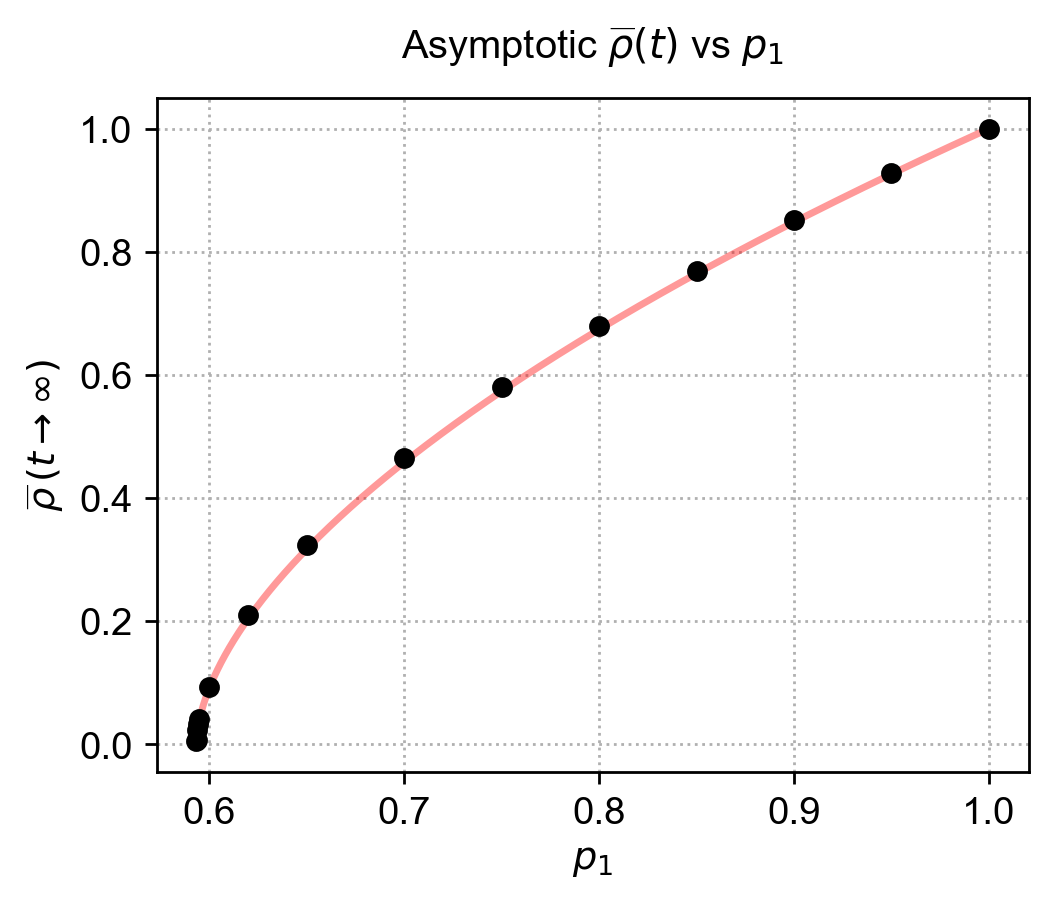

In [25]:
if do_p2:
    p_ρ = p2_ρ
    p_c = float(p_ρ.T[-1][0])
    p_0 = p_c
else:
    p_ρ = p1_ρ
    p_c = float(p_ρ.T[-1][0])
    # p_c = 0.553
    p_0 = p_c

plot_ρ_p(p_ρ[0, :], p_ρ[1, :], p_c, p_0, do_loglog=False, do_p2=do_p2, do_model=True,)
p_c

In [26]:
def plot_φ_τ(
        τ: NDArray, φ: NDArray, 
        τ_c: float, τ_0: float, φ_scale: float=1.7,
        do_loglog=False,
    ):
    fig = viz.create_figure(fig_name="", fig_size=(4.5, 3.5,),)
    plt.title(
        "Model bedload transport   $\\widebar\\varphi^{\!*}(\\tau^{\!*})$",
        fontdict={"fontsize": 11.5}, y=1.03,
    )
    β = 0.5834
    plt.plot(τ, φ, "ko", ms=5, lw=1,)
    τ_model = np.linspace(0, 2, 5001, endpoint=True,)
    # φ_model = φ_scale * ((τ_model-τ_c)*np.heaviside(τ_model-τ_c,0))**β
    φ_model = φ_scale * ((τ_model-τ_c)*np.heaviside(τ_model-τ_c,0))**β * τ_model
    offset = 1
    x = τ_model[offset:]
    y = φ_model[offset:]
    plt.plot(
        x, y, "r", lw=2, alpha=0.4, label=r"$\overline{\rho} \sim |p_1 - p_c|^{0.5834}$",
    )
    plt.ylabel(r"Deduced Einstein number   $\varphi^{\!*}$   $[-]$")
    plt.xlabel(r"Deduced Shields stress   $\tau^{\!*}$   $[-]$")
    plt.semilogy()
    # plt.loglog()
    plt.ylim(8.5e-5, 6.5e-1)
    # plt.ylim(8.5e-5, 10)
    plt.xlim(0, 0.285)
    # plt.xlim(1e-2, 1)
    plt.grid(ls=":")

In [27]:
p_1 = p1_ρ[0, :]
ρ = p1_ρ[1, :]
p_c = float(p1_ρ.T[-1][0])

# # p_1 = τ^* + 0.55
# p_0 = 0.57
# τ = (p_1 - p_0)*2
# τ_c = (p_c - p_0)*2
# τ_0 = p_0
# φ_scale = 1.1

# # p_1 = τ^* + 0.55
# p_0 = 0.54
# τ = (p_1 - p_0)
# τ_c = (p_c - p_0)
# τ_0 = p_0
# φ_scale = 1.7

# # p_1 = 1.5τ + 0.52
# p_0 = 0.52
# τ = (p_1 - p_0)/1.5
# τ_c = (p_c - p_0)/1.5
# τ_0 = p_0
# φ_scale = 2.1

# p_1 = 1.9τ^* + 0.5
p_0 = 0.5
τ = (p_1 - p_0)/1.9
τ_c = (p_c - p_0)/1.9
τ_0 = p_0/1.9
φ_scale = 2.4

# # p_1 = 2τ^* + 0.49
# p_0 = 0.49
# τ = (p_1 - p_0)/2
# τ_c = (p_c - p_0)/2
# τ_0 = p_0
# φ_scale = 2.5

# # p_1 = 3τ + 0.45
# p_0 = 0.45
# τ = (p_1 - p_0)/3
# τ_c = (p_c - p_0)/3

φ = ρ * τ
# φ = ρ

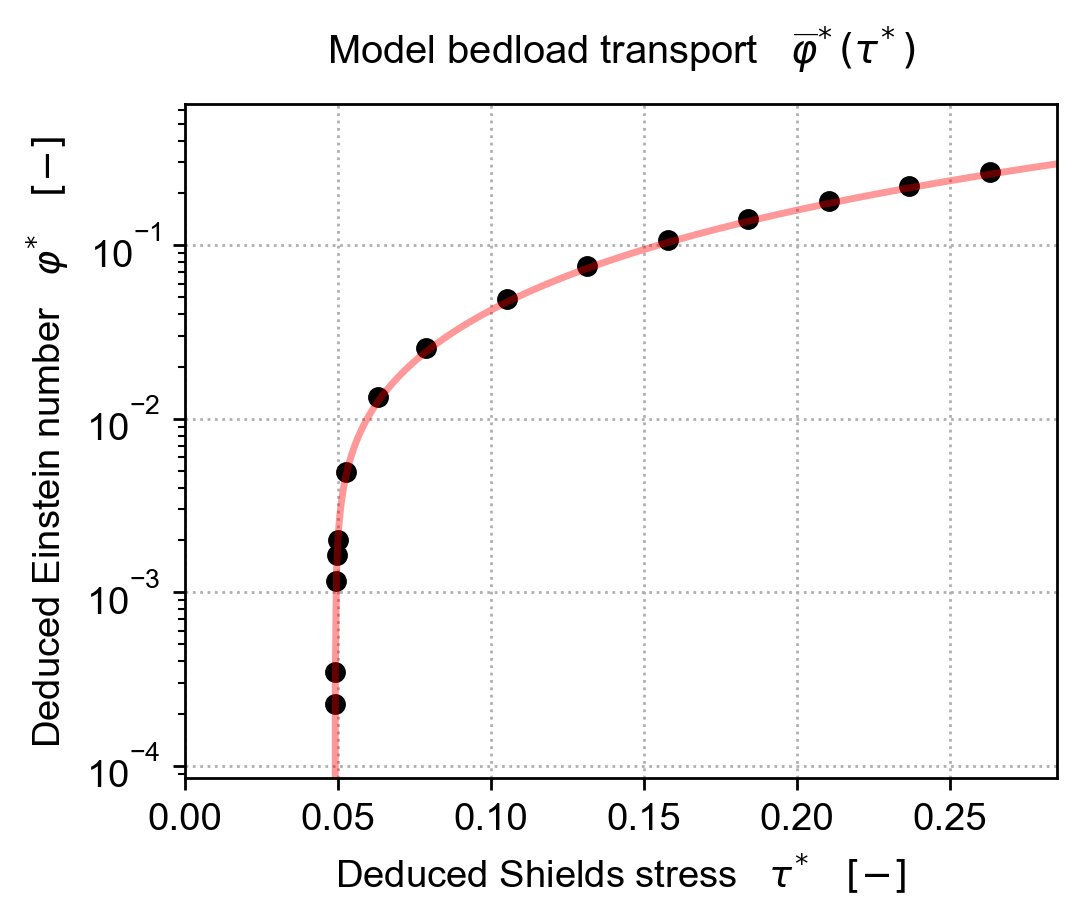

In [28]:
plot_φ_τ(τ, φ, τ_c, τ_0, φ_scale, do_loglog=True,)